<h2>Approximation Algorithms for Vertex Cover</h2>

n this note, we revisit the vertex cover problem which has been introduced previously. Our goal is to examine two greedy algorithms: one that will strike most students as natural, when faced with the vertex cover problem, and one that on first glance does not seem such a good idea but can provide much better approximation guarantees.

Credit: I must acknowledge Prof. Jeff Erickson's exposition on this topic. It has served as a great source for my notes which will add a few more details including some visualizations in Python -- <a href="https://jeffe.cs.illinois.edu/teaching/algorithms/notes/J-approx.pdf">Click Here</a>

<h3>Vertex Cover Problem</h3>
Consider an undirected graph  𝐺   with vertices  𝑉={1,…,𝑛}   and undirected edges  𝐸. Since the graph is  undirected, we consider edges  (𝑖,𝑗) and  (𝑗,𝑖) to be the same.

<b>Vertex Cover</b>: A vertex cover of the graph is a subset  𝐶⊆𝑉  such that every edge  𝑒∈𝑉  has at least one of its end points in the set  𝐶.

Note that the entire vertex set  𝑉 is trivially a vertex cover. The <u>vertex cover problem</u> asks for the <u>smallest size</u> (cardinality) vertex cover for a given undirected graph  𝐺.

<u> Real world example usage  of vertex cover </u> - Suppose a graph  𝐺
  has nodes that represent people and edges between people denote the fact that they are facebook friends. Suppose you are an advertiser who wishes to advertise but sending an advertisement to each person costs you money. When you advertise to someone your ad will show up in their friend's facebook timeline. What is the minimum number of people you need to advertise so that your ad will show up on everyone's timeline? The answer is a minimum vertex cover of the graph  𝐺.

We have seen previously that the problem is NP-complete and can be solved in many ways including a reduction to integer linear programming.

Here, we consider fast algorithms for computing an approximate vertex cover and our natural choice is to consider greedy algorithms.

Consider the example below where we show a graph with five nodes and the nodes in the vertex cover shaded in orange. In fact, the set  {1,4,5}  is a vertex cover but there is in fact a smaller vertex cover consisting just the nodes  {4,5}.



In [2]:
import networkx as nx
from matplotlib import pyplot as plt
from pylab import rcParams

# Use matplotlib and networkx to plot graphs with a designated
# vertex cover passed in as a list of vertices.
# n: number of vertices
# edge_list: list of edges. please ensure that if edge (i,j) 
#            is present then (j,i) is not. We will not be checking this.
# vert_cover: list of vertices in the cover to highlight in orange.
# All nodes will be plotted in blue with vertex cover highlighted in orange.
def plot_graph_with_vc(n, edge_list, vert_cover):
    g = nx.Graph()
    g.add_edges_from(edge_list)
    pos = nx.spring_layout(g)  # positions for all nodes
    not_vert_cover = [i for i in range(1, n+1) if i not in vert_cover]
    plt.figure(1)
    nx.draw_networkx_nodes(g, pos, nodelist=vert_cover,  node_color="tab:orange")
    nx.draw_networkx_nodes(g, pos, nodelist=not_vert_cover,  node_color="tab:blue")
    nx.draw_networkx_edges(g, pos, edgelist=edge_list)
    nx.draw_networkx_labels(g, pos, font_size=12, font_color="whitesmoke")
    plt.show()
    

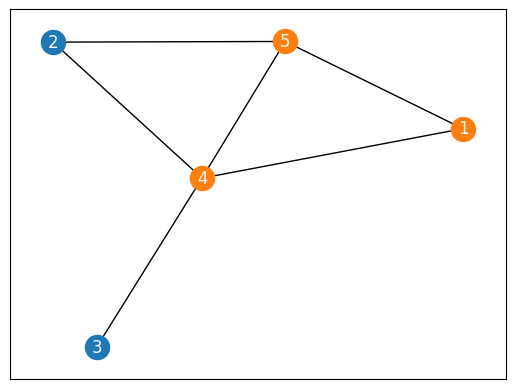

In [3]:
edge_list=[ (1,4), (1,5), (2,5), (2,4), (3,4), (4,5)]
vert_cover = [1,  4, 5]
plot_graph_with_vc(5, edge_list, vert_cover)

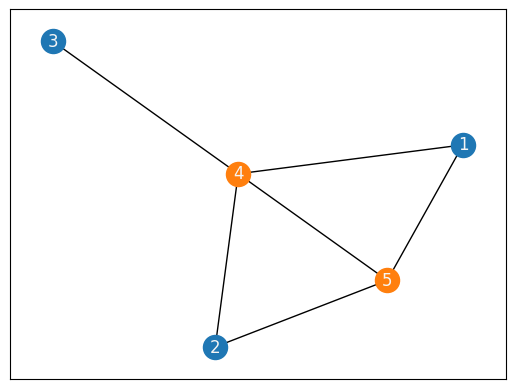

In [4]:
edge_list=[ (1,4), (1,5), (2,5), (2,4), (3,4), (4,5)]
smaller_vert_cover = [4, 5]
plot_graph_with_vc(5, edge_list, smaller_vert_cover)

In [5]:
from pulp import * 

def compute_optimal_vertex_cover(n, edge_list):
    prob = LpProblem('vert_cover', LpMinimize)
    dvars = [LpVariable(f'w_{i}', cat='Binary') for i in range(1, n+1)]
    prob += lpSum(dvars) # minimuze the sum of the variables
    for (i, j) in edge_list:
        assert 1 <= i <= n 
        assert 1 <= j <= n
        prob += dvars[i-1] + dvars[j-1] >= 1 # wi + wj >= 1
    stat = prob.solve()
    assert stat == LpStatusOptimal
    vert_cover = [i+1 for i in range(n) if dvars[i].varValue > 0 ]
    return vert_cover

<h2>Greedy Algorithm for Vertex Cover.</h2>

First recall that the <u>degree of a node is simply the number of edges that are incident on it</u>. Let's start with a simple greedy algorithm:

<b>Greedy Algorithm (Maximum degree)</b> for Vertex Cover:
1. While there are edges left in the graph:
       1.1 Choose the node i with largest degree (break ties arbitrarily).
       1.2 Add node i to the vertex cover
       1.3 Delete all incident edges on node  𝑖

For the example above, the greedy algorithm performs as follows:

1. Vertex  4 has degree  4 and is the highest.
2. Choose this vertex as part of the vertex cover.
3. Remove all its incident edges.
4. Among the remaining vertices (after edges have been deleted), vertex  5  has the highest degree.
5. Add vertex  5 to the cover, delete all its incident edges.
6. No more edges are left.
7. The greedy algorithm returns the cover  {4,5} which is actually optimal!




In [6]:

def greedy_vertex_cover(n, orig_edge_list): 
    edge_list = [(i,j) if i < j else (j,i) for (i,j) in orig_edge_list] 
    # self-note - edge_list provides uniform edge definition since it is undirected graph. Same edge will not get duplicated in adjacency list
    # Construct an adjacency list representation -- for every vertex collect all incident edges.
    adj_list = [set() for i in range(n+1)] #self-note - using set() for adjacency list. Looks 0th set is for doing some purpose
    for (i, j) in edge_list:
        adj_list[i].add(j)
        adj_list[j].add(i)
    # store an array of degrees with the vertex id
    # negate the adjacency degree to get a maxheap
    degrees_with_vert_id = [(-float('inf'),0)] + [(len(adj_list[i]), i) for i in range(1,n+1)]
    num_edges_remaining = len(edge_list)
    # vertex cover list
    vert_cover = []
    while num_edges_remaining >= 1:
        max_degree_vert, vert_id = max(degrees_with_vert_id) # this would be faster if we used a priority queue
        print(f'Adding vertex: {vert_id} of degree {max_degree_vert} to the cover')
        vert_cover.append(vert_id)
        # now delete the edges incident on this vertex and update the degrees
        for j in adj_list[vert_id]: # iterate through all incident edges
            # remove all edges adjacent to vertex vert_id
            adj_list[j].remove(vert_id)
            num_edges_remaining -= 1
            # adjust the degrees
            (dj,_) = degrees_with_vert_id[j]
            degrees_with_vert_id[j] = (dj-1, j)
        degrees_with_vert_id[vert_id] = (0, vert_id)
        adj_list[vert_id] = set() 
    print('All edges removed')
    return vert_cover
  

In [7]:
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML     
def animate_algorithm_result(n, edge_list, vert_cover,ax):
    g = nx.Graph()
    g.add_edges_from(edge_list)
    pos = nx.spring_layout(g)  # positions for all nodes
    def update(i):
        ax.clear()
        vertices_in_cover = vert_cover[:i]
        edges_covered = [(i,j) for (i,j) in edge_list if i in vertices_in_cover or j in vertices_in_cover]
        vertices_not_in_cover = [i for i in range(1,n+1) if i not in vertices_in_cover]
        edges_not_yet_covered = [(i,j) for (i,j) in edge_list if i not in vertices_in_cover and j not in vertices_in_cover]
        nx.draw_networkx_nodes(g, pos, ax = ax, nodelist=vertices_in_cover, node_size=1000, node_color="tab:orange")
        nx.draw_networkx_nodes(g, pos, ax = ax, nodelist=vertices_not_in_cover, node_size=800, node_color="tab:blue")
        nx.draw_networkx_edges(g, pos, ax = ax, edgelist=edges_covered, edge_color="gray", style="dashed")
        nx.draw_networkx_edges(g, pos, ax = ax, edgelist=edges_not_yet_covered, edge_color="black")
        nx.draw_networkx_labels(g, pos, ax = ax, font_size=12, font_color="whitesmoke")
    ani = FuncAnimation(fig, update, frames=len(vert_cover)+1)
    return HTML(ani.to_jshtml())
    

In [8]:
%matplotlib inline
edge_list=[ (1,4), (1,5), (2,5), (2,4), (3,4), (4,5)]
vcover = greedy_vertex_cover(5, edge_list)
#plot_graph_with_vc(5, edge_list, vcover)
fig, ax = plt.subplots(figsize=(6,4))
anim = animate_algorithm_result(5, edge_list, vcover, ax)
plt.close()
anim



Adding vertex: 4 of degree 4 to the cover
Adding vertex: 5 of degree 2 to the cover
All edges removed


In [9]:
# Let's compare it with the optimal vertex cover.
opt_vcover = compute_optimal_vertex_cover(5, edge_list)
print(opt_vcover)
print(f'Optimal vertex cover has {len(opt_vcover)} vertices')

[4, 5]
Optimal vertex cover has 2 vertices


<h2>Example 2</h2>

In [10]:
edge_list=[ (1,4), (1,5), (2,5), (2,4), (3,4), (4,5),(1,8),(2,7), (7,8),(4,6), (5,7), (6,8), (3,1)]
vcover = greedy_vertex_cover(8, edge_list)
#plot_graph_with_vc(8, edge_list, vcover)
fig, ax = plt.subplots(figsize=(6,4))
anim = animate_algorithm_result(8, edge_list, vcover, ax)
plt.close()
anim

Adding vertex: 4 of degree 5 to the cover
Adding vertex: 8 of degree 3 to the cover
Adding vertex: 5 of degree 3 to the cover
Adding vertex: 7 of degree 1 to the cover
Adding vertex: 3 of degree 1 to the cover
All edges removed


[3, 4, 5, 7, 8]
Optimal vertex cover has 5 vertices


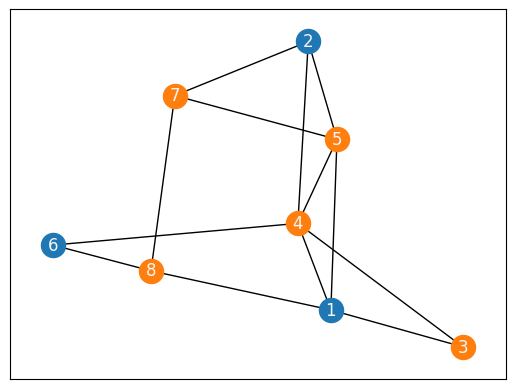

In [11]:
# Let's compare with the optimal vertex cover

opt_vcover = compute_optimal_vertex_cover(8, edge_list)
print(opt_vcover)
print(f'Optimal vertex cover has {len(opt_vcover)} vertices')
plot_graph_with_vc(8, edge_list, opt_vcover)

<h3>Example 3: Randomly generated graph</h3>

Adding vertex: 3 of degree 13 to the cover
Adding vertex: 2 of degree 11 to the cover
Adding vertex: 23 of degree 9 to the cover
Adding vertex: 5 of degree 9 to the cover
Adding vertex: 17 of degree 8 to the cover
Adding vertex: 20 of degree 7 to the cover
Adding vertex: 14 of degree 7 to the cover
Adding vertex: 9 of degree 6 to the cover
Adding vertex: 4 of degree 5 to the cover
Adding vertex: 18 of degree 4 to the cover
Adding vertex: 16 of degree 4 to the cover
Adding vertex: 25 of degree 3 to the cover
Adding vertex: 6 of degree 3 to the cover
Adding vertex: 22 of degree 2 to the cover
Adding vertex: 19 of degree 2 to the cover
Adding vertex: 21 of degree 1 to the cover
Adding vertex: 12 of degree 1 to the cover
All edges removed
Size of cover: 17


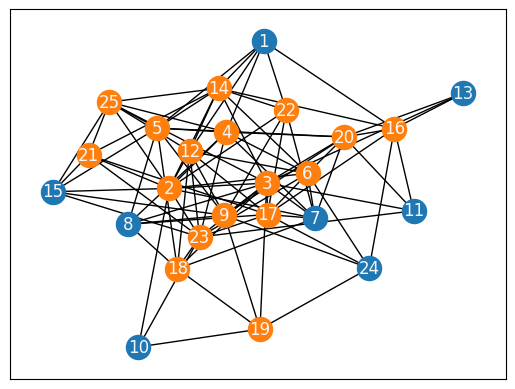

In [13]:
from random import randint
n = 25
edge_list = [ ]
for _ in range(120):
    i = randint(1, n)
    j = randint(1, n)
    if i == 0 or j == 0 or i == j or (i,j) in edge_list or (j,i) in edge_list: 
        continue
    edge_list.append((i,j))

vcover = greedy_vertex_cover(n, edge_list)
print(f'Size of cover: {len(vcover)}')
plot_graph_with_vc(n, edge_list, vcover)


[1, 2, 3, 5, 6, 7, 8, 12, 15, 16, 19, 20, 21, 22, 23, 24, 25]
Optimal vertex cover has 17 vertices


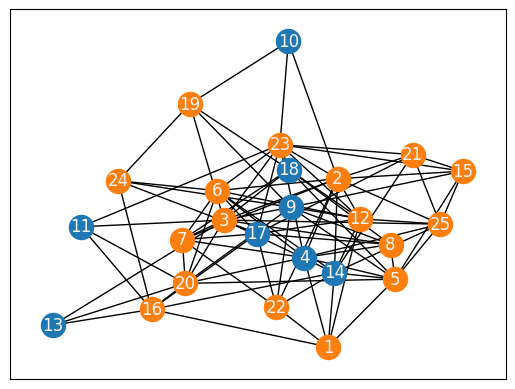

In [14]:
opt_vcover = compute_optimal_vertex_cover(n, edge_list)
print(opt_vcover)
print(f'Optimal vertex cover has {len(opt_vcover)} vertices')
plot_graph_with_vc(n, edge_list, opt_vcover)

<h3>Analysis of Greedy Vertex Cover</h3>

So how does the greedy algorithm we have presented, thus far, perform in terms of the optimal vertex cover? We tried three examples and noticed that in two out of three, the greedy algorithm matched the optimal size vertex cover and in one of the graphs, it was quite close. Therefore, we expect the greedy algorithm to have performance very close to that of the optimal cover, right?

<h3>Worst Case</h3>
In the worst case, the greedy algorithm's performance can be as far away as  𝛼log(𝑛) times that of the optimal, where  𝑛 is the number of nodes in the graph and  𝛼 is some constant that we will not worry about too much.

To show this, we construct a family of examples  𝐺2,𝐺3,…,  of increasing size where for each example  𝐺𝑘, the greedy algorithm will find a vertex cover of size roughly  𝑘log(𝑘) while the optimal cover will be of size  𝑘.

The back-bone of the construction is a set of vertices that we will label - 𝑎1,…,𝑎𝑛 - Secretly the vertex cover will consist simply of these vertices.

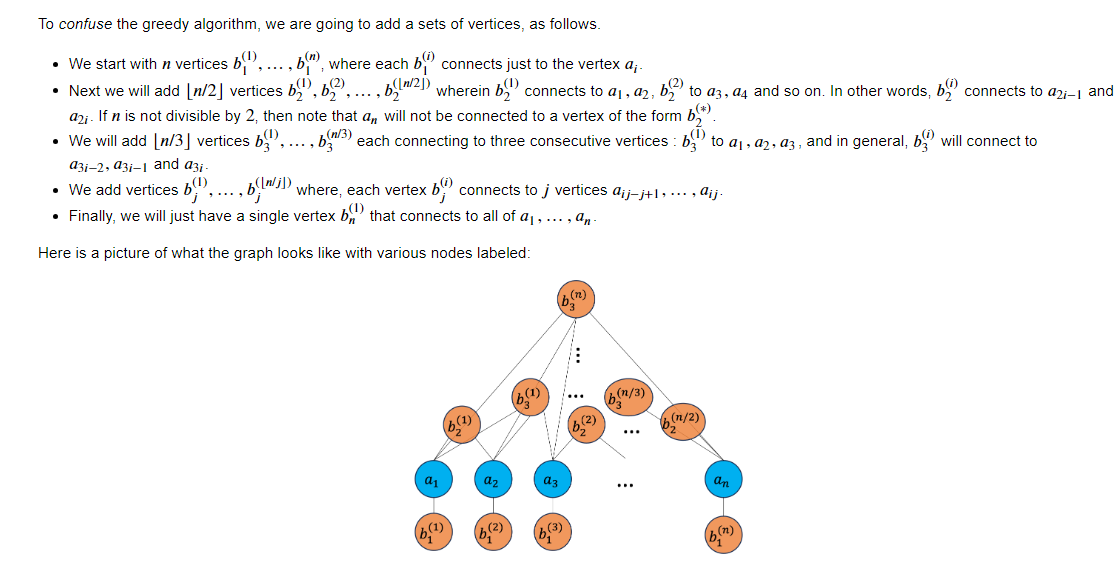

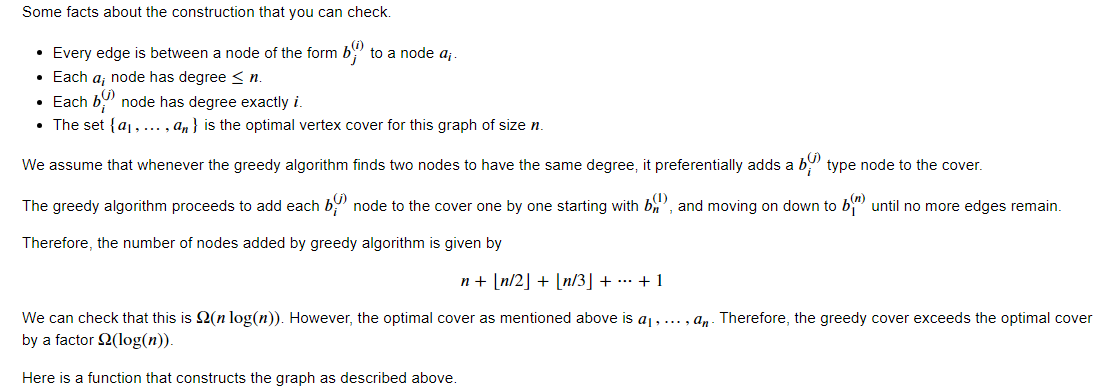




In [16]:
def make_bad_example_for_greedy(n):
    num_vertices = n # start with n vertices 
    edge_list = [] # empty list of edges
    vert_labels = [f'a_{i}' for  i in range(1, n+1)] # we will name the vertices a_1, ..., a_n so far
    for i in range(1, n+1): # run through i from 1 to n inclusive
        j_lim = n//i # compute floor(n/i)
        cur_vert = 1
        for j in range(1, j_lim+1):
            num_vertices = num_vertices + 1
            vert_labels.append(f'b_{i}^{(j)}') # add a new vertex label
            for k in range(i):
                edge_list.append((cur_vert+k, num_vertices)) # add edges from the vertex we just created
            cur_vert += i
    return (num_vertices, edge_list, vert_labels)

12
[(1, 5), (2, 6), (3, 7), (4, 8), (1, 9), (2, 9), (3, 10), (4, 10), (1, 11), (2, 11), (3, 11), (1, 12), (2, 12), (3, 12), (4, 12)]
['a_1', 'a_2', 'a_3', 'a_4', 'b_1^1', 'b_1^2', 'b_1^3', 'b_1^4', 'b_2^1', 'b_2^2', 'b_3^1', 'b_4^1']


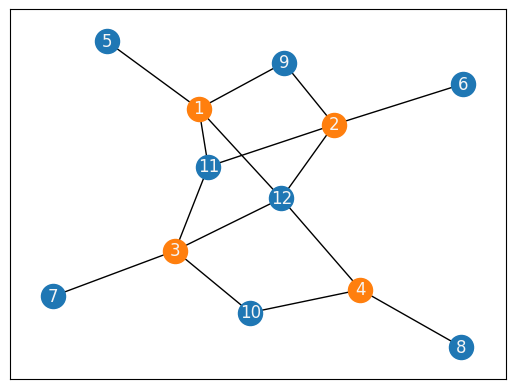

In [17]:
# Let us construct the graph for $n = 4$
(nverts, edge_list, vert_labels) = make_bad_example_for_greedy(4)
print(nverts)
print(edge_list)
print(vert_labels)

opt_cover = [1, 2, 3, 4]
plot_graph_with_vc(nverts, edge_list, opt_cover)


Adding vertex: 12 of degree 4 to the cover
Adding vertex: 11 of degree 3 to the cover
Adding vertex: 10 of degree 2 to the cover
Adding vertex: 9 of degree 2 to the cover
Adding vertex: 8 of degree 1 to the cover
Adding vertex: 7 of degree 1 to the cover
Adding vertex: 6 of degree 1 to the cover
Adding vertex: 5 of degree 1 to the cover
All edges removed
Greedy Cover Size:  8


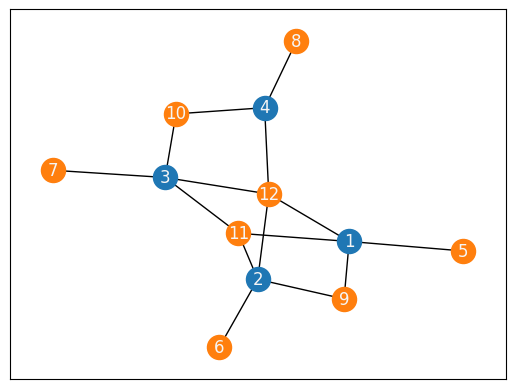

In [18]:
greedy_cover = greedy_vertex_cover(nverts, edge_list)
print('Greedy Cover Size: ', len(greedy_cover))
plot_graph_with_vc(nverts, edge_list, greedy_cover)

15
[(1, 6), (2, 7), (3, 8), (4, 9), (5, 10), (1, 11), (2, 11), (3, 12), (4, 12), (1, 13), (2, 13), (3, 13), (1, 14), (2, 14), (3, 14), (4, 14), (1, 15), (2, 15), (3, 15), (4, 15), (5, 15)]
['a_1', 'a_2', 'a_3', 'a_4', 'a_5', 'b_1^1', 'b_1^2', 'b_1^3', 'b_1^4', 'b_1^5', 'b_2^1', 'b_2^2', 'b_3^1', 'b_4^1', 'b_5^1']


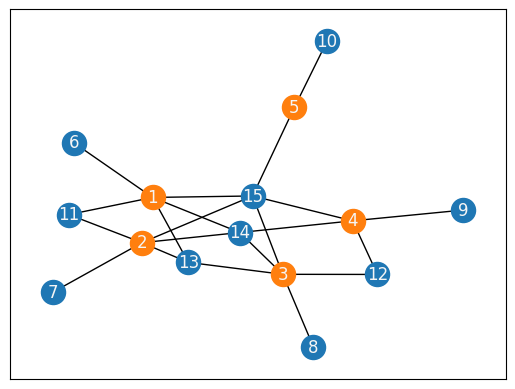

In [19]:
# Let us construct the graph for $n = 5$
n = 5
(nverts, edge_list, vert_labels) = make_bad_example_for_greedy(n)
print(nverts)
print(edge_list)
print(vert_labels)

opt_cover =list(range(1, n+1))

plot_graph_with_vc(nverts, edge_list, opt_cover)


Adding vertex: 15 of degree 5 to the cover
Adding vertex: 14 of degree 4 to the cover
Adding vertex: 13 of degree 3 to the cover
Adding vertex: 12 of degree 2 to the cover
Adding vertex: 11 of degree 2 to the cover
Adding vertex: 10 of degree 1 to the cover
Adding vertex: 9 of degree 1 to the cover
Adding vertex: 8 of degree 1 to the cover
Adding vertex: 7 of degree 1 to the cover
Adding vertex: 6 of degree 1 to the cover
All edges removed
Greedy Cover Size:  10


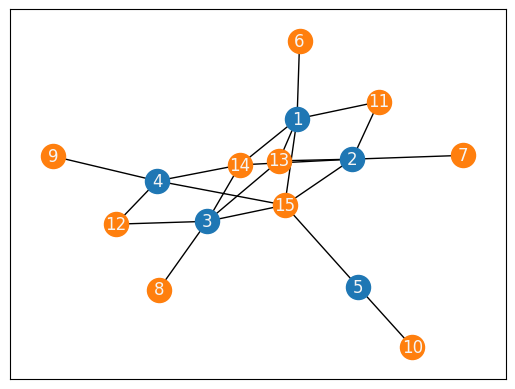

In [20]:
greedy_cover = greedy_vertex_cover(nverts, edge_list)
print('Greedy Cover Size: ', len(greedy_cover))
plot_graph_with_vc(nverts, edge_list, greedy_cover)

20
[(1, 7), (2, 8), (3, 9), (4, 10), (5, 11), (6, 12), (1, 13), (2, 13), (3, 14), (4, 14), (5, 15), (6, 15), (1, 16), (2, 16), (3, 16), (4, 17), (5, 17), (6, 17), (1, 18), (2, 18), (3, 18), (4, 18), (1, 19), (2, 19), (3, 19), (4, 19), (5, 19), (1, 20), (2, 20), (3, 20), (4, 20), (5, 20), (6, 20)]
['a_1', 'a_2', 'a_3', 'a_4', 'a_5', 'a_6', 'b_1^1', 'b_1^2', 'b_1^3', 'b_1^4', 'b_1^5', 'b_1^6', 'b_2^1', 'b_2^2', 'b_2^3', 'b_3^1', 'b_3^2', 'b_4^1', 'b_5^1', 'b_6^1']


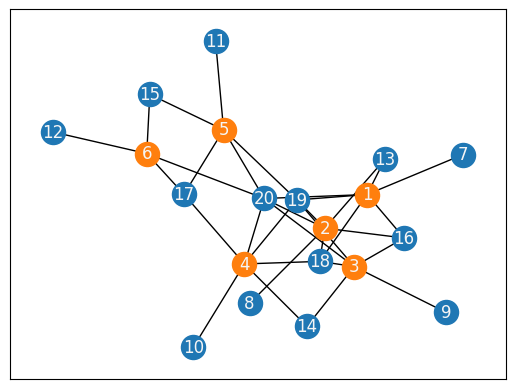

In [21]:
n = 6
(nverts, edge_list, vert_labels) = make_bad_example_for_greedy(n)
print(nverts)
print(edge_list)
print(vert_labels)

opt_cover =list(range(1, n+1))

plot_graph_with_vc(nverts, edge_list, opt_cover)

Adding vertex: 20 of degree 6 to the cover
Adding vertex: 19 of degree 5 to the cover
Adding vertex: 18 of degree 4 to the cover
Adding vertex: 17 of degree 3 to the cover
Adding vertex: 16 of degree 3 to the cover
Adding vertex: 15 of degree 2 to the cover
Adding vertex: 14 of degree 2 to the cover
Adding vertex: 13 of degree 2 to the cover
Adding vertex: 12 of degree 1 to the cover
Adding vertex: 11 of degree 1 to the cover
Adding vertex: 10 of degree 1 to the cover
Adding vertex: 9 of degree 1 to the cover
Adding vertex: 8 of degree 1 to the cover
Adding vertex: 7 of degree 1 to the cover
All edges removed
Greedy Cover Size:  14


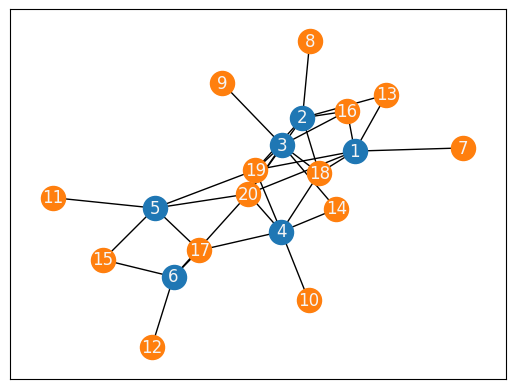

In [22]:
greedy_cover = greedy_vertex_cover(nverts, edge_list)
print('Greedy Cover Size: ', len(greedy_cover))
plot_graph_with_vc(nverts, edge_list, greedy_cover)

<h4>Approximation Ratio for the Greedy Algorithm</h4>

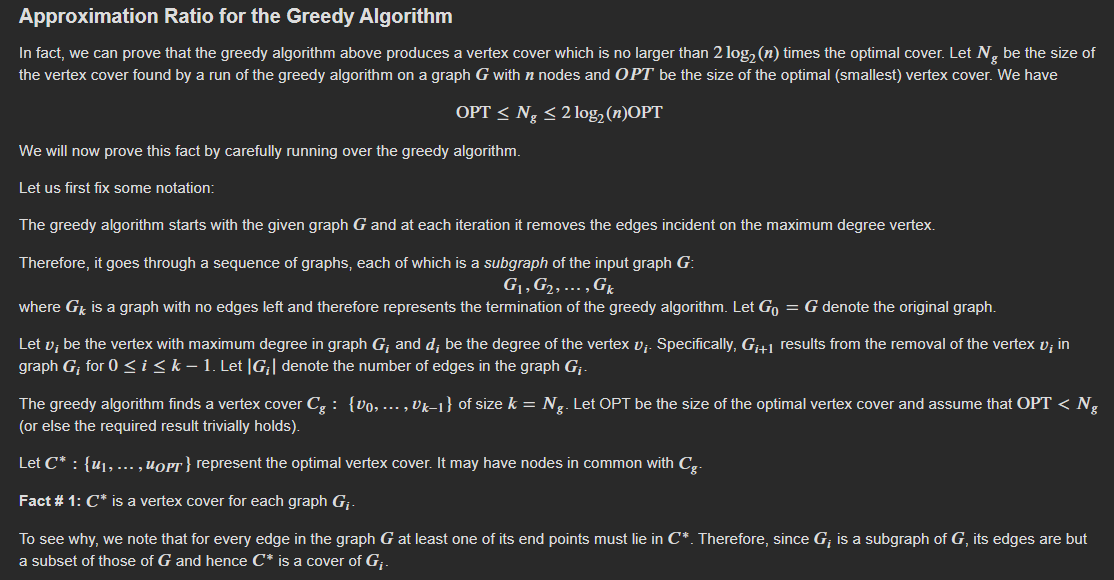

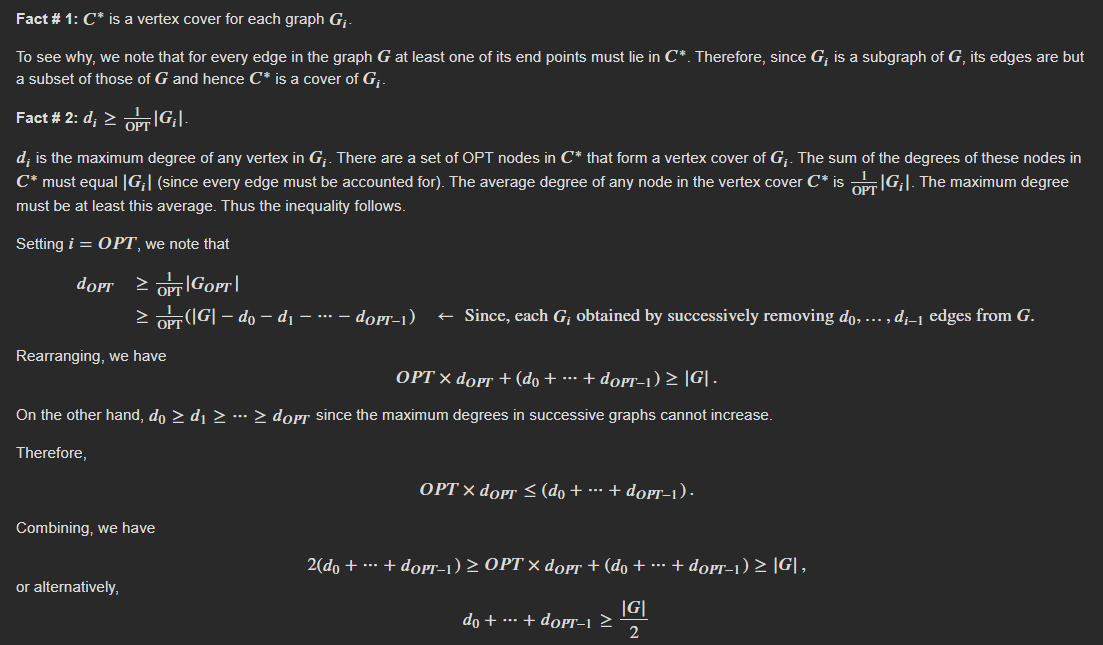

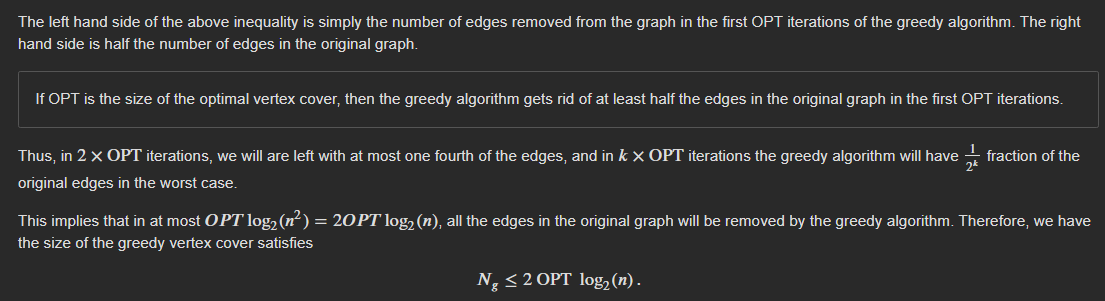

<h3>Greedy Algorithm Based on Matching</h3>
Let us consider a different greedy approach to finding a vertex cover.

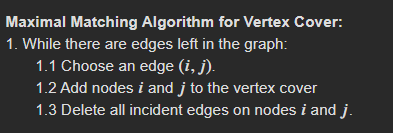

Here the idea is to choose an edge in some arbitrary order, add both the end points of the chosen edge to our cover and delete all edges incident on the two vertices that were just added to the cover.

Let's code this up and run through examples.

In [23]:
def matching_based_vertex_cover(n, edge_list):
    vertex_cover = [] 
    remaining_edges = list(edge_list)
    while len(remaining_edges) > 0:
        (i,j) = remaining_edges[0]
        vertex_cover.append(i)
        vertex_cover.append(j)
        remaining_edges = [(l,m) for (l,m) in remaining_edges if l != i and l != j and m != i and m != j]
        print(f'adding nodes {i}, {j} to the cover')
    return vertex_cover

adding nodes 1, 4 to the cover
adding nodes 2, 5 to the cover


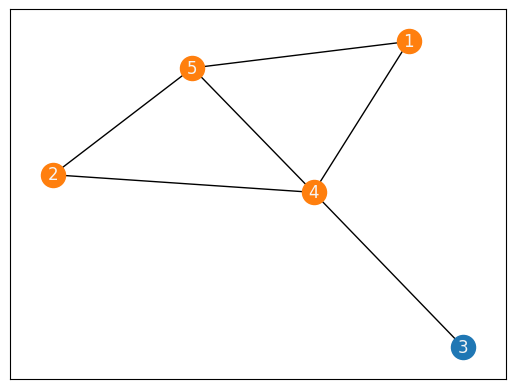

In [24]:
edge_list=[ (1,4), (1,5), (2,5), (2,4), (3,4), (4,5)]
vcover = matching_based_vertex_cover(5, edge_list)
plot_graph_with_vc(5, edge_list, vcover)

adding nodes 1, 4 to the cover
adding nodes 2, 5 to the cover
adding nodes 7, 8 to the cover


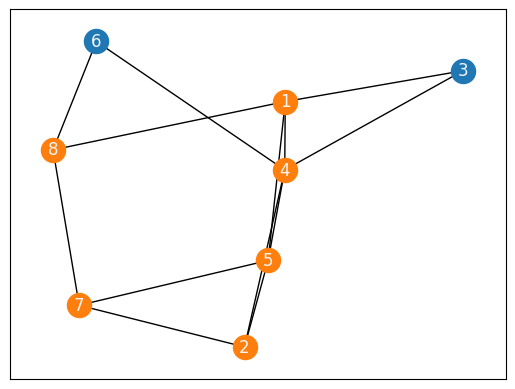

In [25]:
edge_list=[ (1,4), (1,5), (2,5), (2,4), (3,4), (4,5),(1,8),(2,7), (7,8),(4,6), (5,7), (6,8), (3,1)]
vcover = matching_based_vertex_cover(8, edge_list)
plot_graph_with_vc(8, edge_list, vcover)

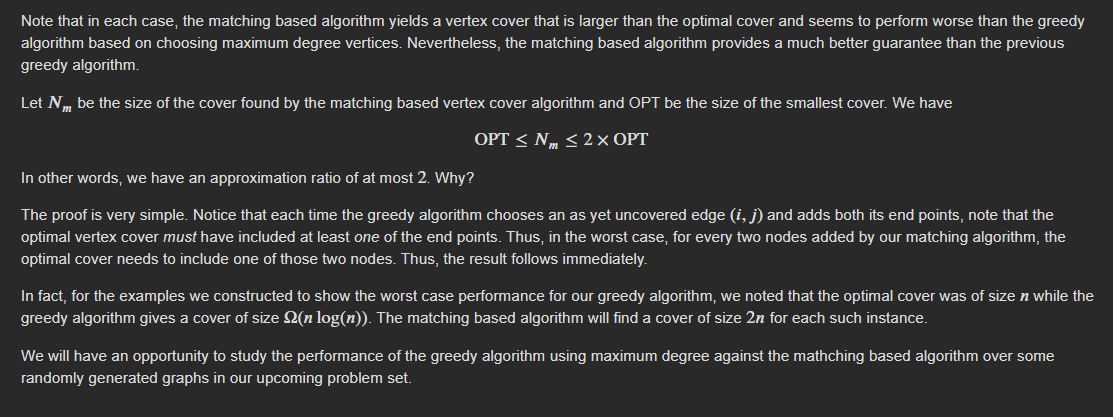